## 7.5 alternate: trapz synthetic photometry + GP (notebook 8 style)

**Workflow:** trapz integration + GP fitting run in a **compute** cell and saved to `Outputs/<SN>/<SN>_trapz_gp_lc_cache.pkl` (or `..._trapz_gp_lc_cache_rjf.pkl` when `USE_RJF_FINAL_SPECTRA=True` in the config cell); use the following **plot** cell to load the pickle and adjust figures without redoing trapz. The compute cell can add **`SYNTHETIC_ONLY_BANDS`** (no photometry in the CSV): those bands get per-epoch **synphot** AB mags (`effstim('abmag')`) for plotting (see [AB magnitude](https://en.wikipedia.org/wiki/AB_magnitude)), while bands with photometry still use trapz flux + empirical `zp` to match the catalog.

**Difference vs [7.5_comparison_check_log.ipynb](7.5_comparison_check_log.ipynb):**

- **Integration:** λ-weighted trapezoid rule as in `FinalLC.band_flux` ([8_Final_Template.ipynb](8_Final_Template.ipynb)), not `synphot` `Observation` / `effstim`.
- **Wavelength grid:** each FINAL spectrum is integrated on its **native** sampling after `read_final_spline_linear` (log10→linear as in the log pipeline). No shared `create_lookup_table` grid and no zero-padding outside coverage.
- **Time axis:** filename stem → MJD via `stem_to_spec_mjd` / `fitted_phot_logspace` (same as 7.5), not notebook 8’s `convert2mjd` on `_REmangled_*` only.
- **Smoothing:** this notebook runs an **active** 1D `george` GP in flux space (the copy of notebook 8 in this repo has the GP block commented out, so `dicts_LC_gp` there is just raw points).
- **Magnitudes:** trapz flux is not AB-calibrated by construction. We apply one **empirical additive zeropoint per band** so `-2.5 log10(f_trapz) + zp` matches your catalog mags at epochs within `dt_match_days`. Compare **shape** and residuals; absolute calibration still follows your observational system.
- **Notebook plot:** the main comparison uses `prepare_trapz_gp_comparison` plus a **local** matplotlib cell so you can change markers, colors (`BAND_COLORS`), axis limits, `SHOW_TRAPZ` / `SHOW_OBS`, legacy `SHOW_GP`, synthetic line mode `SYNTH_LINE_MODE` (`gp`, `smooth_trapz`, `trapz_linear`, `none`), optional `FIG_SAVE_PATH` / `FIG_SAVE_DPI` (save to disk or `None` to only show), and GP knobs (`GP_LENGTH_SCALE_DAYS`, …) without editing the module. Bands with cached **`abmag`** use synphot AB for scatter/lines/GP (mag domain); others use **`-2.5 log10(f_trapz)+zp`** matched to photometry. **Dual legends:** black semantic proxies (synthetic line, photometry) plus a **filter** legend with underscores removed from names.
- **Band names:** `BANDS` must match the photometry CSV `band` column **exactly** (e.g. `DECam_g` vs `DECAM_g`). Misspellings raise `UserWarning` with near-match suggestions from the file.
- **Phase / MJD0:** x-axis is **phase (days since explosion)** from `pipeline_config.SN_EXPLOSION_MJD` when `PHASE_REFERENCE_MJD = None` in the plot cell. The GP time grid spans **both** synthetic spectrum MJDs and observed photometry MJDs so the smooth curve is not clipped to the first spectrum-only epoch.
- **Plot style:** x-axis defaults to **symlog** phase in days. **Observed:** individual points with **white fill**, **band-colored edges**, and error bars (not connected). **Synthetic line** (`SYNTH_LINE_MODE`): GP, smoothed trapz (`UnivariateSpline`), or piecewise-linear trapz; colors follow each band unless `GP_LINE_COLOR` overrides the line. **Trapz** markers (optional): diamonds. Observations are drawn on top (`zorder`).

**Dependencies:** `george` (e.g. `pip install george`). Also `synphot` / `astropy` for the optional diagnostic cell.

The legacy helper `compare_trapz_gp_to_observed_photometry` still exists but emits `DeprecationWarning`; prefer prepare + local plotting here.

**Contrast vs [`plotting-final.ipynb`](plotting-final.ipynb) (wavelength slice):** this notebook compares **band-integrated** trapz flux (and optional 1D GP in flux space) to observed photometry in the same band. `plotting-final` typically plots **monochromatic** \(F_\lambda\) vs phase from a **2D** SED interpolation (`griddata`). Those views answer different questions; use both as needed.


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import george  # noqa: F401
except ImportError as e:
    raise ImportError(
        "Install george for GP smoothing: pip install george"
    ) from e

import pipeline_config as pconf

_REPO = os.path.normpath(pconf.COCO_PATH.rstrip(os.sep))
_CODES_DIR = os.path.join(_REPO, "Codes")
if not os.path.isfile(os.path.join(_CODES_DIR, "comparison_trapz_lc.py")):
    raise FileNotFoundError("Expected %s" % os.path.join(_CODES_DIR, "comparison_trapz_lc.py"))
if _CODES_DIR not in sys.path:
    sys.path.insert(0, _CODES_DIR)

from comparison_check_log_utils import resolve_final_directory
from comparison_trapz_lc import (
    collect_trapz_lightcurves,
    prepare_trapz_gp_comparison,
    smooth_lightcurve_gp,
    collect_synphot_abmag_per_epoch,
    fit_empirical_mag_zp,
)


In [2]:
# Mirror 7.5_comparison_check_log configuration
COCO_PATH = pconf.COCO_PATH
FILTER_PATH = os.path.join(COCO_PATH, "Inputs", "Filters", "GeneralFilters")
FILTERS_PARENT = os.path.join(COCO_PATH, "Inputs", "Filters")
SNNAME = "AT2017gfo"
DATALC_PATH = os.path.join(COCO_PATH, "Inputs", "Photometry", "4_LCs_late_extrapolated")
FINAL_FLUX_ON_DISK = "auto"
FINAL_VARIANT = "as_observed"
FINAL_SUFFIXES_TO_LOAD = None  # or e.g. ("_FINAL_spec_FL.txt",)
# If True, FINAL spectra from NB6/7 *_rjf (FINAL_spectra_2dim/twodim_rjf/...). Re-run compute so trapz cache matches.
USE_RJF_FINAL_SPECTRA = False
USE_RYANV2_FINAL_SPECTRA = True  # if True: FINAL under twodim_ryanv2/... (NB6/7 *_ryanv2)
TWODIM_MODE_FOR_FINAL = pconf.MODE_EXTRAPOLATE_SHORT
TWODIM_PRODUCT_FOR_FINAL = pconf.SUBDIR_FULL_GP
TWODIM_BRANCH = pconf.final_spectra_twodim_branch(
    TWODIM_MODE_FOR_FINAL, TWODIM_PRODUCT_FOR_FINAL,
    use_rjf=USE_RJF_FINAL_SPECTRA and not USE_RYANV2_FINAL_SPECTRA,
    use_ryanv2=USE_RYANV2_FINAL_SPECTRA,
)
_TRAPZ_CACHE_SUFFIX = "_rjf" if USE_RJF_FINAL_SPECTRA else ""

PHOTOMETRY_LONG_CSV = os.path.join(
    COCO_PATH, "Inputs", "Photometry", "1_LCs_flux_raw", "%s.dat" % SNNAME
)

data_dir = resolve_final_directory(
    COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=TWODIM_BRANCH
)
print("FINAL dir:", data_dir)
print(
    "Explosion MJD (default phase t0):",
    pconf.SN_EXPLOSION_MJD.get(
        SNNAME, "(not in SN_EXPLOSION_MJD — plot cell falls back to min photometry MJD with warning)"
    ),
)


FINAL dir: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/twodim_ryanv2/extrapolate/full_gp/as_observed
Explosion MJD (default phase t0): 57982.52851852


### Trapz + GP cache workflow

1. **Run the compute cell below** (slow): reads **all unique `band` values** from the raw photometry CSV (`PHOTOMETRY_LONG_CSV` / `1_LCs_flux_raw`), builds trapz synthetic LCs from FINAL spectra, fits the empirical magnitude zeropoint per band, runs the 1D GP in flux space, and writes **`CACHE_PATH`** (pickle under `Outputs/<SN>/`).
2. **Run the plot cell** (fast): load the pickle and adjust `MODE`, `BANDS_PLOT`, `SHOW_OBS` / `SHOW_TRAPZ`, legacy `SHOW_GP`, `SYNTH_LINE_MODE` (GP / smoothed trapz spline / piecewise-linear trapz / none), `BAND_COLORS`, optional **`FIG_SAVE_PATH`** / `FIG_SAVE_DPI` (set a file path to write the figure; leave `FIG_SAVE_PATH` `None` to only display), and styling without re-integrating spectra.

- **Re-run compute** when FINAL spectra, raw photometry, `data_dir`, or trapz/GP-at-save settings change.
- **`RECOMPUTE_GP = True`** refits the GP **only when** `SYNTH_LINE_MODE="gp"` (cached trapz only; no trapz rerun).
- **Many bands on one axis** makes a crowded legend; set `BANDS_PLOT` to a subset or use `MODE="by_suffix"`.
- **`SYNTHETIC_ONLY_BANDS`** (compute cell): include trapz for filters with **no** photometry; **synphot** `abmag` per epoch (standard AB band mags; [AB magnitude](https://en.wikipedia.org/wiki/AB_magnitude)). **`zp=0`** is only for the raw trapz flux column; the plot uses `abmag` when present. Union with CSV bands is automatic. Add names to `BANDS_PLOT`; `SHOW_OBS=False` for synthetic-only figures. **Re-run compute** after changes.


In [4]:
import os
import pickle
import time

import numpy as np
import pandas as pd

import pipeline_config as pconf

# ---- expensive: edit GP-at-save and paths, then run once ----
RAW_PHOTOMETRY_PATH = PHOTOMETRY_LONG_CSV  # same as config cell; raw 1_LCs_flux_csv
PHASE_REFERENCE_MJD = None  # None -> pipeline_config.SN_EXPLOSION_MJD[SNNAME]
DT_MATCH_DAYS = 2.0
# Trapz + synphot AB mags (per epoch) for bands with **no** photometry rows; add exact `band` names here.
SYNTHETIC_ONLY_BANDS = ('LSST_g', 'LSST_i', 'LSST_r', 'LSST_u', 'LSST_Y', 'LSST_z')

GP_N_PREDICT = 512
GP_OPTIMIZE = True
GP_LENGTH_SCALE_DAYS = 3.0
GP_LENGTH_SCALE_FACTOR = 1.0

OUTPUT_ROOT = pconf.outputs_root(COCO_PATH)
CACHE_PATH = os.path.join(
    OUTPUT_ROOT, SNNAME, "%s_trapz_gp_lc_cache%s.pkl" % (SNNAME, _TRAPZ_CACHE_SUFFIX)
)
CACHE_VERSION = 1

# -----------------------------------------------------------------

_df = pd.read_csv(RAW_PHOTOMETRY_PATH)
bands_all = sorted(_df["band"].dropna().astype(str).unique())
print("%i unique bands in %s" % (len(bands_all), RAW_PHOTOMETRY_PATH))

bands_for_prep = sorted(set(bands_all) | set(SYNTHETIC_ONLY_BANDS))
if len(bands_for_prep) > len(bands_all):
    print(
        "%i bands for cache (photometry + %i synthetic-only extra)"
        % (len(bands_for_prep), len(bands_for_prep) - len(bands_all))
    )

prep = prepare_trapz_gp_comparison(
    data_dir,
    COCO_PATH,
    SNNAME,
    RAW_PHOTOMETRY_PATH,
    bands_for_prep,
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
    mjd0=PHASE_REFERENCE_MJD,
    dt_match_days=DT_MATCH_DAYS,
    synthetic_only_bands=SYNTHETIC_ONLY_BANDS,
)
t0 = float(prep["mjd0"])
print("Phase zero MJD (t0):", t0)

_cache = {
    "version": CACHE_VERSION,
    "created_unix": time.time(),
    "snname": SNNAME,
    "mjd0": t0,
    "photometry_csv": os.path.abspath(str(RAW_PHOTOMETRY_PATH)),
    "data_dir": data_dir,
    "dt_match_days": float(DT_MATCH_DAYS),
    "twodim_branch": TWODIM_BRANCH,
    "final_variant": FINAL_VARIANT,
    "gp_compute": {
        "GP_N_PREDICT": int(GP_N_PREDICT),
        "GP_OPTIMIZE": bool(GP_OPTIMIZE),
        "GP_LENGTH_SCALE_DAYS": float(GP_LENGTH_SCALE_DAYS),
        "GP_LENGTH_SCALE_FACTOR": float(GP_LENGTH_SCALE_FACTOR),
    },
    "bands": {},
}

for _band, d in prep["bands"].items():
    mjd = np.asarray(d["mjd"], dtype=float)
    flx = np.asarray(d["flux"], dtype=float)
    fe = np.asarray(d["flux_err"], dtype=float)
    obs = d["obs"].copy()
    zp = float(d["zp"])
    n_zp = int(d["n_zp_matches"])
    m_tr = np.isfinite(mjd) & np.isfinite(flx) & np.isfinite(fe) & (fe > 0)
    tgrid = None
    gp_mu = None
    gp_sig = None
    tgrid_ab = None
    gp_mu_ab = None
    gp_sig_ab = None
    mab = d.get("abmag")
    mag_gp_ok = False
    if mab is not None:
        mab = np.asarray(mab, dtype=float)
        mabe = np.asarray(
            d.get("abmag_err", np.full_like(mab, np.nan)), dtype=float
        )
        mabe = np.where(np.isfinite(mabe) & (mabe > 0), mabe, 0.05)
        m_tr_ab = np.isfinite(mjd) & np.isfinite(mab) & (mabe > 0)
        if m_tr_ab.sum() >= 3:
            t_syn_lo = float(np.min(mjd[m_tr_ab]))
            t_syn_hi = float(np.max(mjd[m_tr_ab]))
            obs_mjd = obs["MJD"].values.astype(float)
            if obs_mjd.size > 0 and np.any(np.isfinite(obs_mjd)):
                t_obs_lo = float(np.nanmin(obs_mjd))
                t_obs_hi = float(np.nanmax(obs_mjd))
                t_lo = min(t_syn_lo, t_obs_lo)
                t_hi = max(t_syn_hi, t_obs_hi)
            else:
                t_lo, t_hi = t_syn_lo, t_syn_hi
            tgrid_ab = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
            gp_mu_ab, gp_sig_ab = smooth_lightcurve_gp(
                mjd[m_tr_ab],
                mab[m_tr_ab],
                mabe[m_tr_ab],
                tgrid_ab,
                optimize=GP_OPTIMIZE,
                length_scale_days=GP_LENGTH_SCALE_DAYS,
                length_scale_factor=GP_LENGTH_SCALE_FACTOR,
            )
            mag_gp_ok = True
    if not mag_gp_ok and m_tr.sum() >= 3:
        t_syn_lo = float(np.min(mjd[m_tr]))
        t_syn_hi = float(np.max(mjd[m_tr]))
        obs_mjd = obs["MJD"].values.astype(float)
        if obs_mjd.size > 0 and np.any(np.isfinite(obs_mjd)):
            t_obs_lo = float(np.nanmin(obs_mjd))
            t_obs_hi = float(np.nanmax(obs_mjd))
            t_lo = min(t_syn_lo, t_obs_lo)
            t_hi = max(t_syn_hi, t_obs_hi)
        else:
            t_lo, t_hi = t_syn_lo, t_syn_hi
        tgrid = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
        gp_mu, gp_sig = smooth_lightcurve_gp(
            mjd[m_tr],
            flx[m_tr],
            fe[m_tr],
            tgrid,
            optimize=GP_OPTIMIZE,
            length_scale_days=GP_LENGTH_SCALE_DAYS,
            length_scale_factor=GP_LENGTH_SCALE_FACTOR,
        )
    ent = {
        "mjd": mjd,
        "flux": flx,
        "flux_err": fe,
        "zp": zp,
        "n_zp_matches": n_zp,
        "obs": obs,
        "gp_tgrid": tgrid,
        "gp_mu": gp_mu,
        "gp_sig": gp_sig,
        "gp_tgrid_ab": tgrid_ab,
        "gp_mu_ab": gp_mu_ab,
        "gp_sig_ab": gp_sig_ab,
    }
    if mab is not None:
        ent["abmag"] = np.asarray(d["abmag"], dtype=float)
        ent["abmag_err"] = np.asarray(d["abmag_err"], dtype=float)
    _cache["bands"][_band] = ent

os.makedirs(os.path.dirname(os.path.abspath(CACHE_PATH)), exist_ok=True)
with open(CACHE_PATH, "wb") as _f:
    pickle.dump(_cache, _f, protocol=4)
print(
    "Wrote cache: %s (%i bands)"
    % (os.path.abspath(CACHE_PATH), len(_cache["bands"]))
)


69 unique bands in /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat
75 bands for cache (photometry + 6 synthetic-only extra)


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_21962/2608257361.py:41: UserWarning: Band 'LSST_Y': synthetic-only (no photometry). Using synphot AB mags (abmag) plus zp=0 on trapz flux only.
  prep = prepare_trapz_gp_comparison(
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_21962/2608257361.py:41: UserWarning: Band 'LSST_g': synthetic-only (no photometry). Using synphot AB mags (abmag) plus zp=0 on trapz flux only.
  prep = prepare_trapz_gp_comparison(
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_21962/2608257361.py:41: UserWarning: Band 'LSST_i': synthetic-only (no photometry). Using synphot AB mags (abmag) plus zp=0 on trapz flux only.
  prep = prepare_trapz_gp_comparison(
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_21962/2608257361.py:41: UserWarning: Band 'LSST_r': synthetic-only (no photometry). Using synphot AB mags (abmag) plus zp=0 on trapz flux only.
  prep = prepare_trapz_gp_comparison(
/var/folders/0n/xfstb8sn23ldhmmxkvnl

Phase zero MJD (t0): 57982.52851852
Wrote cache: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/AT2017gfo_trapz_gp_lc_cache.pkl (75 bands)


In [15]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.interpolate import UnivariateSpline

import pipeline_config as pconf

def _maybe_save_fig(fig, path, suffix=None):
    """Save *fig* if *path* is a non-empty string or Path; otherwise do nothing.

    In ``MODE=='by_suffix'``, pass ``suffix=suff`` so each file is
    ``<stem>_<suffix><ext>`` (e.g. ``lc_g.png``).
    """
    if path is None or str(path).strip() == "":
        return
    from pathlib import Path

    p = Path(path).expanduser()
    out = (
        (p.parent / ("%s_%s%s" % (p.stem, suffix, p.suffix)))
        if suffix is not None
        else p
    )
    out.parent.mkdir(parents=True, exist_ok=True)
    dpi = int(globals().get("FIG_SAVE_DPI", 150))
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print("Saved figure ->", out)


def _effective_synth_mode():
    if not SHOW_GP:
        return "none"
    m = SYNTH_LINE_MODE
    if m not in _VALID_SYNTH_MODES:
        raise ValueError(
            "SYNTH_LINE_MODE must be one of %s, got %r"
            % (sorted(_VALID_SYNTH_MODES), m)
        )
    return m


def _band_color(band):
    i = bands_plot.index(band)
    if BAND_COLORS is None:
        return colors[i % len(colors)]
    if isinstance(BAND_COLORS, dict):
        return BAND_COLORS.get(band, colors[i % len(colors)])
    if isinstance(BAND_COLORS, (list, tuple)):
        if len(BAND_COLORS) != len(bands_plot):
            raise ValueError(
                "BAND_COLORS length %d != bands_plot length %d"
                % (len(BAND_COLORS), len(bands_plot))
            )
        return BAND_COLORS[i]
    raise TypeError("BAND_COLORS must be None, dict, or list/tuple")


def _pseudo_mag_per_epoch(d, zp):
    """Magnitude per epoch: synphot AB if present, else trapz pseudo-mag with zp."""
    if d.get("abmag") is not None:
        ab = np.asarray(d["abmag"], dtype=float)
        if ab.size and np.any(np.isfinite(ab)):
            return ab
    flx = np.asarray(d["flux"], dtype=float)
    return -2.5 * np.log10(np.maximum(flx, 1e-300)) + float(zp)


def _trapz_sorted_finite(syn_phase, pseudo, s_sort):
    ph = syn_phase[s_sort]
    mag = pseudo[s_sort]
    m = np.isfinite(ph) & np.isfinite(mag)
    ph, mag = ph[m], mag[m]
    if ph.size == 0:
        return None, None
    o = np.argsort(ph)
    return ph[o], mag[o]


def _uniq_phase_avg_mag(ph, mag):
    """Mean mag at each distinct phase so x is strictly increasing (for splines / interp)."""
    if ph.size <= 1:
        return ph, mag
    u_ph, inv = np.unique(ph, return_inverse=True)
    if u_ph.size == ph.size:
        return ph, mag
    wsum = np.bincount(inv, weights=mag)
    cnt = np.bincount(inv)
    return u_ph, wsum / cnt


def _smooth_trapz_line(syn_phase, pseudo, s_sort):
    ph, mag = _trapz_sorted_finite(syn_phase, pseudo, s_sort)
    if ph is None or ph.size < 2:
        return None, None
    ph, mag = _uniq_phase_avg_mag(ph, mag)
    if ph.size < 2:
        return None, None
    n = int(max(2, N_TRAPZ_LINE))
    tgrid = np.linspace(float(ph[0]), float(ph[-1]), n)
    if ph.size == 2:
        mag_g = np.interp(tgrid, ph, mag)
        return tgrid, mag_g
    k = int(min(3, ph.size - 1))
    spl = UnivariateSpline(ph, mag, s=TRAPZ_SPLINE_S, k=k)
    return tgrid, spl(tgrid)


def _trapz_linear_line(syn_phase, pseudo, s_sort):
    ph, mag = _trapz_sorted_finite(syn_phase, pseudo, s_sort)
    if ph is None or ph.size < 2:
        return None, None
    ph, mag = _uniq_phase_avg_mag(ph, mag)
    if ph.size < 2:
        return None, None
    return ph, mag


def _add_dual_legends(ax, bands_for_legend, legend2_kwargs=None):
    mode = _effective_synth_mode()
    h_a, lbl_a = [], []
    if mode != "none":
        h_a.append(Line2D([0], [0], color="k", lw=LINE_WIDTH))
        lbl_a.append("Synthetic light curve")
    if SHOW_OBS:
        h_a.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="none",
                markeredgecolor="k",
                markeredgewidth=OBS_MARKER_EDGE_WIDTH,
                linestyle="None",
                markersize=OBS_MARKER_SIZE * 0.85,
            )
        )
        lbl_a.append("Photometry")
    if h_a:
        leg1 = ax.legend(h_a, lbl_a, loc="lower left", framealpha=0.92, fontsize=12)
        ax.add_artist(leg1)
    fh = [
        Line2D([0], [0], color=_band_color(b), lw=2.8, solid_capstyle="round")
        for b in bands_for_legend
    ]
    fl = [b.replace("_", " ") for b in bands_for_legend]
    if not fh:
        return
    kw = dict(title="Filter", loc="upper right", framealpha=0.92, fontsize=12)
    if legend2_kwargs:
        kw.update(legend2_kwargs)
    ax.legend(fh, fl, **kw)


def _gp_mag_for_band(_band, d, _color):
    """Return (phase_plot_mjd, mag_gp) using cache or refit (flux or synphot AB space)."""
    if _effective_synth_mode() != "gp":
        return None, None
    mjd = np.asarray(d["mjd"], dtype=float)
    obs = d["obs"]
    use_ab = d.get("abmag") is not None and np.any(
        np.isfinite(np.asarray(d["abmag"], dtype=float))
    )
    if use_ab:
        mab = np.asarray(d["abmag"], dtype=float)
        mabe = np.asarray(
            d.get("abmag_err", np.full_like(mab, np.nan)), dtype=float
        )
        mabe = np.where(np.isfinite(mabe) & (mabe > 0), mabe, 0.05)
        m_tr = np.isfinite(mjd) & np.isfinite(mab) & (mabe > 0)
        if m_tr.sum() < 3:
            return None, None
        if RECOMPUTE_GP:
            t_syn_lo = float(np.min(mjd[m_tr]))
            t_syn_hi = float(np.max(mjd[m_tr]))
            obs_mjd = obs["MJD"].values.astype(float)
            if obs_mjd.size > 0 and np.any(np.isfinite(obs_mjd)):
                t_obs_lo = float(np.nanmin(obs_mjd))
                t_obs_hi = float(np.nanmax(obs_mjd))
                t_lo = min(t_syn_lo, t_obs_lo)
                t_hi = max(t_syn_hi, t_obs_hi)
            else:
                t_lo, t_hi = t_syn_lo, t_syn_hi
            tgrid = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
            mu, _sig = smooth_lightcurve_gp(
                mjd[m_tr],
                mab[m_tr],
                mabe[m_tr],
                tgrid,
                optimize=GP_OPTIMIZE,
                length_scale_days=GP_LENGTH_SCALE_DAYS,
                length_scale_factor=GP_LENGTH_SCALE_FACTOR,
            )
        else:
            tgrid = d.get("gp_tgrid_ab")
            mu = d.get("gp_mu_ab")
            if tgrid is None or mu is None:
                return None, None
        return tgrid - t0, mu
    flx = d["flux"]
    fe = d["flux_err"]
    zp = float(d["zp"])
    m_tr = np.isfinite(mjd) & np.isfinite(flx) & np.isfinite(fe) & (fe > 0)
    if m_tr.sum() < 3:
        return None, None
    if RECOMPUTE_GP:
        t_syn_lo = float(np.min(mjd[m_tr]))
        t_syn_hi = float(np.max(mjd[m_tr]))
        obs_mjd = obs["MJD"].values.astype(float)
        if obs_mjd.size > 0 and np.any(np.isfinite(obs_mjd)):
            t_obs_lo = float(np.nanmin(obs_mjd))
            t_obs_hi = float(np.nanmax(obs_mjd))
            t_lo = min(t_syn_lo, t_obs_lo)
            t_hi = max(t_syn_hi, t_obs_hi)
        else:
            t_lo, t_hi = t_syn_lo, t_syn_hi
        tgrid = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
        mu, _sig = smooth_lightcurve_gp(
            mjd[m_tr],
            flx[m_tr],
            fe[m_tr],
            tgrid,
            optimize=GP_OPTIMIZE,
            length_scale_days=GP_LENGTH_SCALE_DAYS,
            length_scale_factor=GP_LENGTH_SCALE_FACTOR,
        )
    else:
        tgrid = d["gp_tgrid"]
        mu = d["gp_mu"]
        if tgrid is None or mu is None:
            return None, None
    mag_mu = -2.5 * np.log10(np.maximum(mu, 1e-300)) + zp
    return tgrid - t0, mag_mu


def _draw_synthetic_line(ax, band, d, color, gp_color, syn_phase, pseudo, s_sort):
    mode = _effective_synth_mode()
    if mode == "none":
        return
    if mode == "gp":
        gp_x, gp_mag = _gp_mag_for_band(band, d, color)
        if gp_x is not None:
            ax.plot(
                gp_x,
                gp_mag,
                "-",
                color=gp_color,
                lw=LINE_WIDTH,
                alpha=0.7,
                zorder=2,
            )
        return
    if mode == "smooth_trapz":
        lx, lm = _smooth_trapz_line(syn_phase, pseudo, s_sort)
        if lx is not None:
            ax.plot(
                lx,
                lm,
                "-",
                color=gp_color,
                lw=LINE_WIDTH,
                alpha=0.7,
                zorder=2,
            )
        return
    if mode == "trapz_linear":
        lx, lm = _trapz_linear_line(syn_phase, pseudo, s_sort)
        if lx is not None:
            ax.plot(
                lx,
                lm,
                "-",
                color=gp_color,
                lw=LINE_WIDTH,
                alpha=0.7,
                zorder=2,
            )


def plot_panel():
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=FIGSIZE)
    summary_bands = {}
    bands_drawn = []
    ax.axhline(y=22.55, color='hotpink', linestyle='--', alpha=0.5)
    ax.axhline(y=23.56, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y=24.13, color='orange', linestyle='--', alpha=0.5)
    ax.axhline(y=24.52, color='gold', linestyle='--', alpha=0.5)
    ax.axhline(y=24.97, color='limegreen', linestyle='--', alpha=0.5)
    ax.axhline(y=23.70, color='deepskyblue', linestyle='--', alpha=0.5)
    for band in bands_plot:
        if band not in cache["bands"]:
            continue
        d = cache["bands"][band]
        color = _band_color(band)
        gp_color = color if GP_LINE_COLOR is None else GP_LINE_COLOR
        mjd = d["mjd"]
        flx = d["flux"]
        obs = d["obs"]
        zp = float(d["zp"])
        n_zp = int(d["n_zp_matches"])
        pseudo = _pseudo_mag_per_epoch(d, zp)
        syn_phase = mjd - t0
        s_sort = np.argsort(syn_phase)
        _draw_synthetic_line(ax, band, d, color, gp_color, syn_phase, pseudo, s_sort)
        if SHOW_TRAPZ:
            ax.scatter(
                syn_phase[s_sort],
                pseudo[s_sort],
                color=color,
                alpha=0.5,
                zorder=4,
                marker="D",
            )
        if SHOW_OBS and len(obs) > 0:
            obs_mjd = obs["MJD"].values
            obs_mag = obs["Mag"].values
            obs_err = obs["Mag_err"].values
            obs_phase = obs_mjd - t0
            ax.errorbar(
                obs_phase,
                obs_mag,
                yerr=obs_err,
                fmt="o",
                linestyle="none",
                markersize=OBS_MARKER_SIZE,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=OBS_MARKER_EDGE_WIDTH,
                ecolor=color,
                elinewidth=1.2,
                capsize=2.5,
                capthick=1.2,
                alpha=1.0,
                zorder=10,
            )
        summary_bands[band] = {"zp": zp, "n_zp_matches": n_zp, "n_syn": int(mjd.size)}
        bands_drawn.append(band)
    if LOG_TIME_AXIS:
        lt = max(float(LOG_TIME_LINTHRESH_DAYS), 1e-6)
        ax.set_xscale("symlog", linthresh=lt, linscale=1.0, base=10)
        ax.set_xlabel(
            "Phase (days since %.5f MJD; symlog, |phase| < %.3g linear)" % (t0, lt)
        )
    else:
        # ax.set_xlabel("Phase (days since %.5f MJD)" % t0)
        ax.set_xlabel("Phase relative to merger (days)", fontsize=16)
    ax.set_ylabel("AB Magnitude", fontsize=16)
    ax.invert_yaxis()
    ax.set_xlim(-0.1, 0.5)
    #ax.set_title(TITLE)
    _add_dual_legends(ax, bands_drawn)
    ax.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    #ax.set_xlim(0, 26)

    # 3. Increase the font size of the tick labels (adjust '12' to your preference)
    ax.tick_params(axis='both', which='major', labelsize=14)

    #ax.grid(True, which="both", alpha=0.35, linestyle="-", linewidth=0.6)
    fig.tight_layout()
    _maybe_save_fig(fig, FIG_SAVE_PATH)
    plt.show()
    print("Plotted bands:", list(summary_bands.keys()))
    print("Summary:", summary_bands)


def plot_by_suffix():
    plt.rcParams['font.family'] = 'serif'
    # Build combined phase series for global xlim (positive phase only, like plotting-final)
    phases_pos = []
    for band in bands_plot:
        if band not in cache["bands"]:
            continue
        d = cache["bands"][band]
        obs = d["obs"]
        if len(obs) > 0:
            phases_pos.append(obs["MJD"].values.astype(float) - t0)
        phases_pos.append((np.asarray(d["mjd"], dtype=float) - t0,))
    all_p = np.concatenate([np.asarray(x, dtype=float).ravel() for x in phases_pos if len(x)])
    all_p = all_p[np.isfinite(all_p) & (all_p > 0)]
    if all_p.size == 0:
        all_p = np.array([1e-2, 30.0])
    lo, hi = SUFFIX_XLIM_PADDING
    gx0 = float(np.min(all_p) * lo)
    gx1 = float(np.max(all_p) * hi)

    from collections import defaultdict

    suff_groups = defaultdict(list)
    for band in bands_plot:
        if band not in cache["bands"]:
            continue
        suff = str(band).split("_")[-1].lower()
        suff_groups[suff].append(band)

    for suff in sorted(suff_groups.keys()):
        blist = suff_groups[suff]
        fig, ax = plt.subplots(figsize=FIGSIZE)
        bands_drawn = []
        for band in blist:
            d = cache["bands"][band]
            color = _band_color(band)
            mjd = d["mjd"]
            flx = d["flux"]
            obs = d["obs"]
            zp = float(d["zp"])
            pseudo = _pseudo_mag_per_epoch(d, zp)
            syn_phase = mjd - t0
            s_sort = np.argsort(syn_phase)
            gp_color = color if GP_LINE_COLOR is None else GP_LINE_COLOR
            _draw_synthetic_line(ax, band, d, color, gp_color, syn_phase, pseudo, s_sort)
            if SHOW_TRAPZ:
                ax.scatter(
                    syn_phase[s_sort],
                    pseudo[s_sort],
                    color=color,
                    alpha=0.5,
                    zorder=4,
                    marker="D",
                )
            if SHOW_OBS and len(obs) > 0:
                obs_phase = obs["MJD"].values - t0
                ax.errorbar(
                    obs_phase,
                    obs["Mag"].values,
                    yerr=obs["Mag_err"].values,
                    fmt="o",
                    linestyle="none",
                    markersize=OBS_MARKER_SIZE,
                    markerfacecolor="white",
                    markeredgecolor=color,
                    markeredgewidth=1.0,
                    ecolor=color,
                    elinewidth=1.2,
                    capsize=2.5,
                    capthick=1.2,
                    alpha=1.0,
                    zorder=10,
                )
            bands_drawn.append(band)
        #ax.set_xlim(gx0, gx1)
        ax.set_xlim(0, 26)
        if SUFFIX_USE_LOG_X:
            ax.set_xscale("log")
        ax.invert_yaxis()
        ax.set_xlabel("Phase from explosion (days)")
        ax.set_ylabel("AB mag")
        ax.set_title("%s — suffix %s" % (TITLE, suff.upper()))
        _add_dual_legends(
            ax,
            bands_drawn,
            legend2_kwargs={
                "bbox_to_anchor": (1.05, 1),
                "loc": "upper left",
                "fontsize": "small",
                "title": "Filter",
            },
        )
        ax.grid(True, which="both", alpha=0.35, linestyle="-", linewidth=0.6)
        fig.tight_layout()
        _maybe_save_fig(fig, FIG_SAVE_PATH, suffix=suff)
        plt.show()


Saved figure -> /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/plots-for-flash/LSST_lc.png


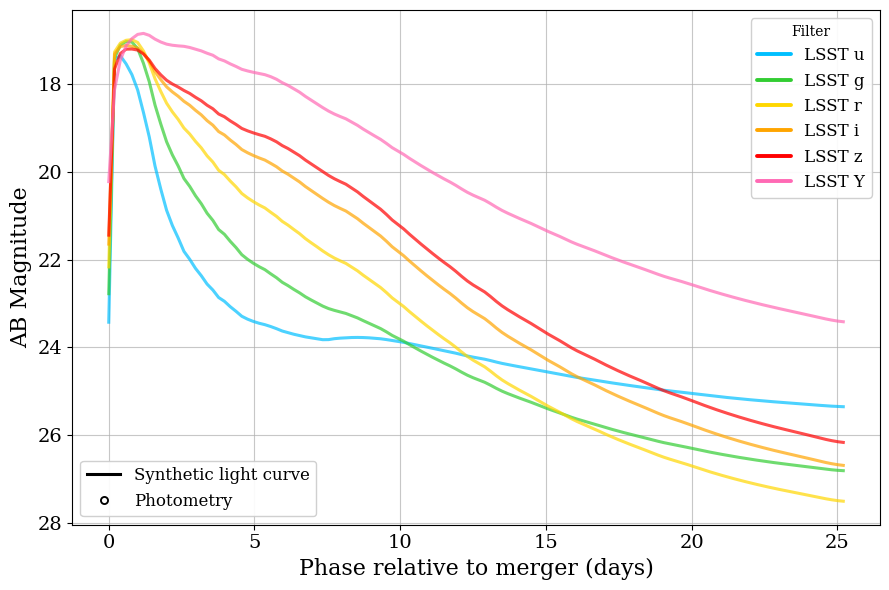

Plotted bands: ['LSST_u', 'LSST_g', 'LSST_r', 'LSST_i', 'LSST_z', 'LSST_Y']
Summary: {'LSST_u': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_g': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_r': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_i': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_z': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_Y': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}}


In [7]:


# ============== load cache ==============
OUTPUT_ROOT = pconf.outputs_root(COCO_PATH)
_trapz_suf = "_rjf" if globals().get("USE_RJF_FINAL_SPECTRA", False) else ""
CACHE_PATH = os.path.join(
    OUTPUT_ROOT, SNNAME, "%s_trapz_gp_lc_cache%s.pkl" % (SNNAME, _trapz_suf)
)

with open(CACHE_PATH, "rb") as f:
    cache = pickle.load(f)

if int(cache.get("version", 0)) != 1:
    raise ValueError("Unexpected cache version %r" % cache.get("version"))

t0 = float(cache["mjd0"])

# ============== plot controls (edit freely) ==============
# MODE: "panel" = one axis, all selected bands; "by_suffix" = one figure per band suffix (e.g. g, r, i)
MODE = "panel"
# None = every band in the cache; or e.g. ("GROND_g", "GROND_r") to declutter
BANDS_PLOT = ('LSST_u', 'LSST_g', 'LSST_r', 'LSST_i', 'LSST_z', 'LSST_Y')
#BANDS_PLOT = ('GROND_g', 'GROND_r', 'GROND_i', 'GROND_z', 'GROND_H', 'GROND_J', 'GROND_K')
#BANDS_PLOT = ('DECam_u', 'DECam_g', 'DECam_r', 'DECam_i', 'DECam_z', 'DECam_Y')
#BANDS_PLOT = ('SIRIUS_J', 'SIRIUS_H', 'SIRIUS_Ks')
#BANDS_PLOT = ('UVOT_W2', 'UVOT_W1', 'UVOT_U', 'UVOT_B')

SHOW_OBS = True
SHOW_TRAPZ = False
# Legacy: if False, no synthetic line is drawn (overrides SYNTH_LINE_MODE).
SHOW_GP = True
# Synthetic line when SHOW_GP is True: "gp" | "smooth_trapz" | "trapz_linear" | "none"
SYNTH_LINE_MODE = "smooth_trapz"
# smooth_trapz: UnivariateSpline smoothing (0 = interpolating spline); evaluation grid size
TRAPZ_SPLINE_S = 0
N_TRAPZ_LINE = 128
# Optional explicit colors: None | dict band -> color | tuple/list same length as bands_plot,
# matching the order of BANDS_PLOT (bands missing from cache are skipped from bands_plot).
BAND_COLORS = ('deepskyblue', 'limegreen', 'gold', 'orange', 'red', 'hotpink')
#BAND_COLORS = ('indigo', 'royalblue', 'deepskyblue', 'cyan')

# Refit GP from cached trapz in the notebook (no spectrum integration); only used when SYNTH_LINE_MODE == "gp"
RECOMPUTE_GP = False
GP_N_PREDICT = 512
GP_OPTIMIZE = True
GP_LENGTH_SCALE_DAYS = 3
GP_LENGTH_SCALE_FACTOR = 1.0

FIGSIZE = (9, 6)
TITLE = "%s: light curves (phase from explosion)" % SNNAME
LOG_TIME_AXIS = False
LOG_TIME_LINTHRESH_DAYS = 1e-2
GP_LINE_COLOR = None
LINE_WIDTH = 2.2
OBS_MARKER_SIZE = 6.0
OBS_MARKER_EDGE_WIDTH = 1.35

# Save figure: set to a file path (str or pathlib.Path), or None / "" to skip.
# by_suffix: writes one file per suffix as <stem>_<suffix><ext> (e.g. Plots/lc_g.png).
FIG_SAVE_PATH = '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/plots-for-flash/LSST_lc.png'
FIG_SAVE_DPI = 500
#FIG_SAVE_PATH = None
XLIM = (0, 25)

# by_suffix: log-scaled positive phase like plotting-final.ipynb
SUFFIX_USE_LOG_X = True
SUFFIX_XLIM_PADDING = 0.9, 1.1  # multiply min/max positive phase
# ----------------------------------------

bands_avail = sorted(cache["bands"].keys())
if BANDS_PLOT is not None:
    bands_plot = [b for b in BANDS_PLOT if b in cache["bands"]]
else:
    bands_plot = list(bands_avail)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_VALID_SYNTH_MODES = frozenset({"gp", "smooth_trapz", "trapz_linear", "none"})



if MODE == "panel":
    plot_panel()
elif MODE == "by_suffix":
    plot_by_suffix()
else:
    raise ValueError("MODE must be 'panel' or 'by_suffix', got %r" % (MODE,))


### Optional: synphot AB mags on the native grid (same epochs)

Per epoch, compare **trapz** pseudo-magnitude (after the same empirical `zp` as above) to **synphot** `effstim('abmag')`. A rough vertical offset between the two is expected; similar **time evolution** means the trapz path is capturing the same SED trend as synphot aside from bandpass-definition differences.

In [16]:
band_diag = "DECam_g"

lc = collect_trapz_lightcurves(
    data_dir,
    COCO_PATH,
    SNNAME,
    [band_diag],
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
)
mjd_t, f_t, fe_t = lc[band_diag]["mjd"], lc[band_diag]["flux"], lc[band_diag]["flux_err"]

import pandas as pd

dfp = pd.read_csv(PHOTOMETRY_LONG_CSV)
obs = dfp[dfp["band"] == band_diag]
_mjd_fallback = float(obs["MJD"].min()) if len(obs) else float(dfp["MJD"].min())
mjd0 = float(pconf.SN_EXPLOSION_MJD.get(SNNAME, _mjd_fallback))
zp, n_zp = fit_empirical_mag_zp(
    mjd_t, f_t, obs["MJD"].values, obs["Mag"].values, dt_match_days=2.0
)
mag_trapz = -2.5 * np.log10(np.maximum(f_t, 1e-300)) + zp
print("diag band %s: zp=%s n_zp_matches=%s len(obs)=%s" % (band_diag, zp, n_zp, len(obs)))

mjd_sp, mag_sp = collect_synphot_abmag_per_epoch(
    data_dir,
    COCO_PATH,
    SNNAME,
    band_diag,
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mjd_t - mjd0, mag_trapz, "s", label="trapz + zp (empirical)", ms=4)
ax.plot(mjd_sp - mjd0, mag_sp, "^", label="synphot effstim (native λ)", ms=4)
ax.set_xlabel("Phase (days since %.5f MJD)" % mjd0)
ax.set_ylabel("AB mag")
ax.set_title("%s: trapz vs synphot (%s)" % (SNNAME, band_diag))
ax.legend()
ax.set_xscale('log')
ax.set_xlim(-0.1,10)
ax.set_ylim(18,24)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


KeyboardInterrupt: 

### Distance-rescaled synthetic light curves (forecast / “what if at $D_{\rm target}$?”)

The trapz cache stores synthetics implied by your **FINAL spectra** at the luminosity distance of the cosmology you assumed when building those spectra — by default observer-frame at **$D_L(z)$** for redshift **`Z_SN`**. Treat that as **`$D_{\rm ref}$`** unless you explicitly set **`REFERENCE_DISTANCE_MPC`**.

For fixed intrinsic luminosity, observer-frame flux scales as **$F_\lambda \propto D_L^{-2}$**.

- **Flux scale:** $\texttt{flux\_scale} = (D_{\rm ref} / D_{\rm target})^{2}$.
- **AB magnitudes (equivalent shift):** $\Delta m = 5 \log_{10}(D_{\rm target} / D_{\rm ref})$ applied to synthetic AB / pseudo magnitudes derived from the same $F_\lambda$.

**Cosmology default:** **`$D_{\rm ref}$`** $=$ **Planck18** `luminosity_distance(Z_SN)` in Mpc (`astropy.cosmology.Planck18`). Optionally override with **`REFERENCE_DISTANCE_MPC`** (e.g. a literature value). Set **`TARGET_DISTANCE_MPC`** (e.g. 200).

**Not the same as `FINAL_VARIANT` / host-galaxy corrections:** those flags pick different **SED products** on disk. This section applies a purely **geometric** inverse-square rescaling **after** whatever SED is already in the pickle.

**Not a survey simulator:** scaled curves ignore depth, noise, extinction, calibration, finite aperture, PSF stacking, detection thresholds, etc. — only homogeneous flux scaling in every band.

**Observed points:** **`SHOW_OBS_DISTANCE_SCALED = False`** by default so the plot is synthetic-only (“forecast”). If **`True`**, catalog photometry is shown **without** rescaling — useful only as rough context — and is **misleading** alongside distance-scaled synthetics unless you deliberately compare shapes at mismatched luminosity distances.

Distance scaling | loaded /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/AT2017gfo_trapz_gp_lc_cache.pkl | D_ref=40 Mpc D_target=200 Mpc | flux_scale=0.04 | Δm=3.4949 mag
Saved figure -> /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/plots-for-flash/LSST_lc.png


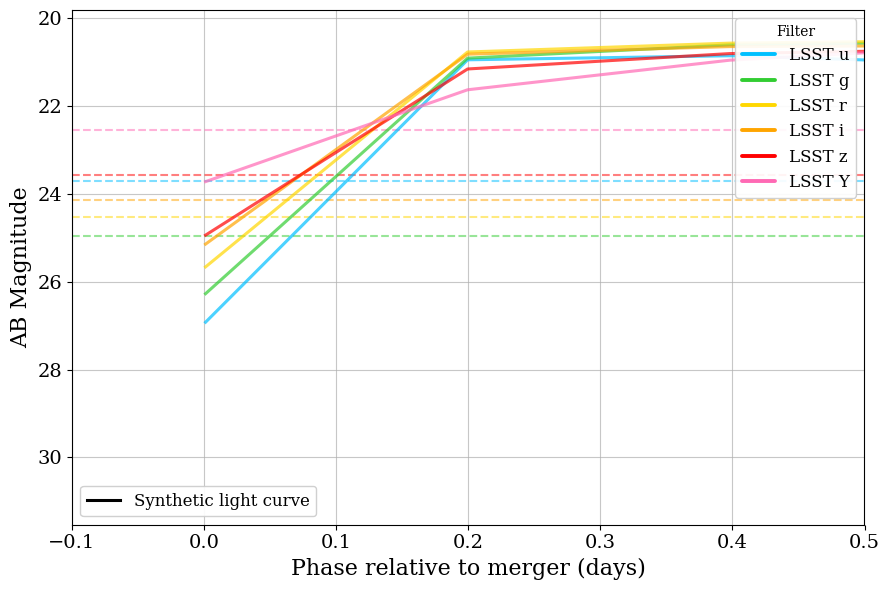

Plotted bands: ['LSST_u', 'LSST_g', 'LSST_r', 'LSST_i', 'LSST_z', 'LSST_Y']
Summary: {'LSST_u': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_g': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_r': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_i': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_z': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}, 'LSST_Y': {'zp': 0.0, 'n_zp_matches': 0, 'n_syn': 266}}


In [17]:
# Distance scaling: multiply cached fluxes by flux_scale; add Δm to AB synthetic mags / GP-ab curve.
from astropy.cosmology import Planck18

# ---- knobs (adjust per science case) ------------------------------------------
TARGET_DISTANCE_MPC = 200.0  # luminosity distance of the hypothetical placement
REFERENCE_DISTANCE_MPC = 40  # None -> Planck18 D_L(Z_SN); else luminosity distance of the pickle (Mpc)
Z_SN = 0.009783  # only used when REFERENCE_DISTANCE_MPC is None (AT2017gfo illustrative)
SHOW_OBS_DISTANCE_SCALED = False  # observed points are **not** rescaled — default off for forecasts
MODE_DISTANCE_SCALED = None  # None -> reuse MODE from plot cell ("panel"|"by_suffix")
FIG_SAVE_PATH_DISTANCE_SCALED = None  # e.g. a path string to save this figure separately; None -> keep FIG_SAVE_PATH
XLIM = (0, 0.5)

OUTPUT_ROOT_DISTANCE = pconf.outputs_root(COCO_PATH)
_trapz_suf_distance = "_rjf" if globals().get("USE_RJF_FINAL_SPECTRA", False) else ""
CACHE_PATH_DISTANCE_SCALED = os.path.join(
    OUTPUT_ROOT_DISTANCE,
    SNNAME,
    "%s_trapz_gp_lc_cache%s.pkl" % (SNNAME, _trapz_suf_distance),
)

with open(CACHE_PATH_DISTANCE_SCALED, "rb") as _fcd:
    cache_distance_src = pickle.load(_fcd)

if int(cache_distance_src.get("version", 0)) != 1:
    raise ValueError("Unexpected cache version %r" % cache_distance_src.get("version"))

if REFERENCE_DISTANCE_MPC is None:
    D_ref = float(Planck18.luminosity_distance(float(Z_SN)).to("Mpc").value)
else:
    D_ref = float(REFERENCE_DISTANCE_MPC)

D_target = float(TARGET_DISTANCE_MPC)
if D_ref <= 0 or D_target <= 0:
    raise ValueError("Require positive luminosity distances; got D_ref=%s, D_target=%s" % (D_ref, D_target))

flux_scale = (D_ref / D_target) ** 2
_dm = 5.0 * np.log10(D_target / D_ref)


def _band_scaled_for_distance(ent, fs, dm_amp):
    o = dict(ent)
    o["flux"] = np.asarray(ent["flux"], dtype=float) * fs
    o["flux_err"] = np.asarray(ent["flux_err"], dtype=float) * fs
    if ent.get("abmag") is not None:
        m = np.asarray(ent["abmag"], dtype=float)
        o["abmag"] = np.where(np.isfinite(m), m + dm_amp, m)
    if ent.get("gp_mu") is not None:
        o["gp_mu"] = np.asarray(ent["gp_mu"], dtype=float) * fs
    if ent.get("gp_sig") is not None:
        o["gp_sig"] = np.asarray(ent["gp_sig"], dtype=float) * fs
    if ent.get("gp_mu_ab") is not None:
        o["gp_mu_ab"] = np.asarray(ent["gp_mu_ab"], dtype=float) + dm_amp
    return o


scaled_cache_distance = dict(cache_distance_src)
scaled_cache_distance["bands"] = {
    bk: _band_scaled_for_distance(bd, flux_scale, _dm)
    for bk, bd in cache_distance_src["bands"].items()
}

print(
    "Distance scaling | loaded %s | D_ref=%.5g Mpc D_target=%.5g Mpc | flux_scale=%.5g | Δm=%.5g mag"
    % (CACHE_PATH_DISTANCE_SCALED, D_ref, D_target, flux_scale, _dm)
)
if SHOW_OBS_DISTANCE_SCALED:
    print("Warning: plotted photometry is **not** distance-scaled; compare to synthetics cautiously.")

# ---- mirror plot-panel style using helpers from plot cell --------------------
_prev_CACHE = globals()["cache"]
_prev_SHOW_OBS = globals()["SHOW_OBS"]
_prev_bands_plot_SENT = object()
_prev_bands_plot = globals().get("bands_plot", _prev_bands_plot_SENT)
_prev_FSP = globals().get("FIG_SAVE_PATH")

try:
    globals()["cache"] = scaled_cache_distance
    globals()["SHOW_OBS"] = SHOW_OBS_DISTANCE_SCALED
    if FIG_SAVE_PATH_DISTANCE_SCALED is not None:
        globals()["FIG_SAVE_PATH"] = FIG_SAVE_PATH_DISTANCE_SCALED

    _bands_avail_ds = sorted(scaled_cache_distance["bands"].keys())
    if globals().get("BANDS_PLOT") is not None:
        globals()["bands_plot"] = [b for b in BANDS_PLOT if b in scaled_cache_distance["bands"]]
    else:
        globals()["bands_plot"] = list(_bands_avail_ds)

    _MODE_DS = globals()["MODE"] if MODE_DISTANCE_SCALED is None else MODE_DISTANCE_SCALED
    if _MODE_DS == "panel":
        plot_panel()
    elif _MODE_DS == "by_suffix":
        plot_by_suffix()
    else:
        raise ValueError("MODE_DISTANCE_SCALED / MODE must be 'panel' or 'by_suffix', got %r" % (_MODE_DS,))
finally:
    globals()["cache"] = _prev_CACHE
    globals()["SHOW_OBS"] = _prev_SHOW_OBS
    globals()["FIG_SAVE_PATH"] = _prev_FSP
    if _prev_bands_plot is not _prev_bands_plot_SENT:
        globals()["bands_plot"] = _prev_bands_plot